# YZM212 Makine Öğrenmesi 4. Laboratuvar Ödevi
## Uzak Bir Galaksinin Parlaklık Analizi

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

In [2]:
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Veri Üretimi
Bu bölümde sentetik gözlem verisi üretilmektedir.

In [3]:
true_mu = 150.0
true_sigma = 10.0
n_obs = 50

np.random.seed(42)
data = true_mu + true_sigma * np.random.randn(n_obs)

print("İlk 10 gözlem:")
print(data[:10])

print("\nÖrnek ortalama:", np.mean(data))
print("Örnek std:", np.std(data, ddof=1))

İlk 10 gözlem:
[154.96714153 148.61735699 156.47688538 165.23029856 147.65846625
 147.65863043 165.79212816 157.67434729 145.30525614 155.42560044]

Örnek ortalama: 147.7452609474386
Örnek std: 9.336687818831116


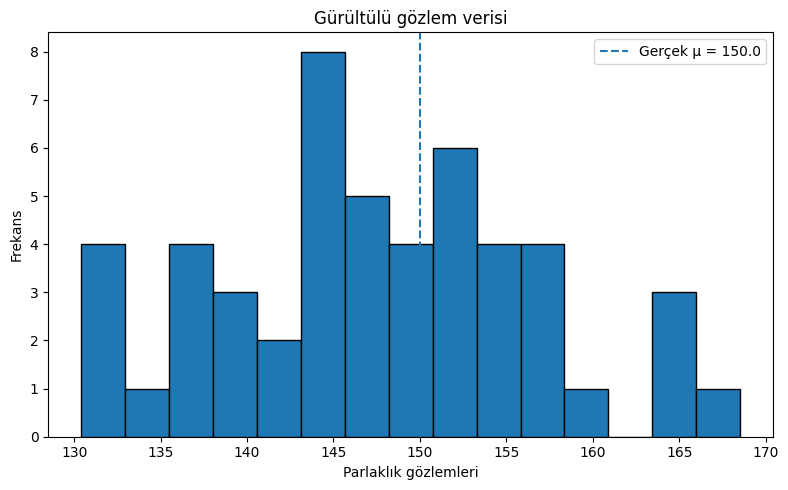

In [4]:
plt.figure(figsize=(8,5))
plt.hist(data, bins=15, edgecolor="black")
plt.axvline(true_mu, linestyle="--", label=f"Gerçek μ = {true_mu}")
plt.xlabel("Parlaklık gözlemleri")
plt.ylabel("Frekans")
plt.title("Gürültülü gözlem verisi")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/data_histogram.png", dpi=300)
plt.show()

## 2. Bayesyen Fonksiyonların Tanımlanması
Bu bölümde log-likelihood, log-prior ve log-posterior tanımlanmıştır.

In [5]:
def log_likelihood(theta, data):
    mu, sigma = theta
    if sigma <= 0:
        return -np.inf
    return -0.5 * np.sum(((data - mu) / sigma)**2 + np.log(2 * np.pi * sigma**2))

def log_prior(theta):
    mu, sigma = theta
    if 0 < mu < 300 and 0 < sigma < 50:
        return 0.0
    return -np.inf

def log_probability(theta, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

## 3. MCMC Örnekleme
Bu bölümde `emcee` kullanılarak MCMC çalıştırılmıştır.

In [6]:
initial = [140, 5]
n_walkers = 32
n_dim = 2

pos = initial + 1e-4 * np.random.randn(n_walkers, n_dim)

sampler = emcee.EnsembleSampler(
    n_walkers, n_dim, log_probability, args=(data,)
)

sampler.run_mcmc(pos, 2000, progress=True)

You must install the tqdm library to use progress indicators with emcee


State([[146.59998341  10.42092649]
 [145.76650675  11.60857143]
 [146.31910041   9.14490759]
 [145.90858789   9.51951477]
 [149.50001792  10.6971051 ]
 [148.23997762   7.57732972]
 [145.92371546   9.17289208]
 [148.26406017  10.31640188]
 [148.47276681   9.17008242]
 [147.57449242  10.21570077]
 [150.23734833   9.44225594]
 [147.03952781   9.89079477]
 [149.14711346  11.12816338]
 [148.27233147   9.8407065 ]
 [148.62613862   9.28586118]
 [145.98667835  10.18979161]
 [145.24739774  10.44528554]
 [149.43608698   9.22811801]
 [146.40245485   8.43770594]
 [145.78330318  10.51884913]
 [147.85401389   8.45182821]
 [147.42844684   9.44192722]
 [149.10109886   8.90341593]
 [146.47069205  10.31726797]
 [147.33120777   8.41840442]
 [148.72370404   8.55018824]
 [147.63410866   8.90291161]
 [147.9781292   10.78401907]
 [148.89230751   8.80346579]
 [147.55857922  11.08242989]
 [149.9933675    9.75677827]
 [147.16186895   9.84247395]], log_prob=[-183.10672788 -185.10921796 -182.75317262 -183.1127120

In [7]:
chain = sampler.get_chain()
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

print("Chain shape:", chain.shape)
print("Flat samples shape:", flat_samples.shape)

Chain shape: (2000, 32, 2)
Flat samples shape: (3200, 2)


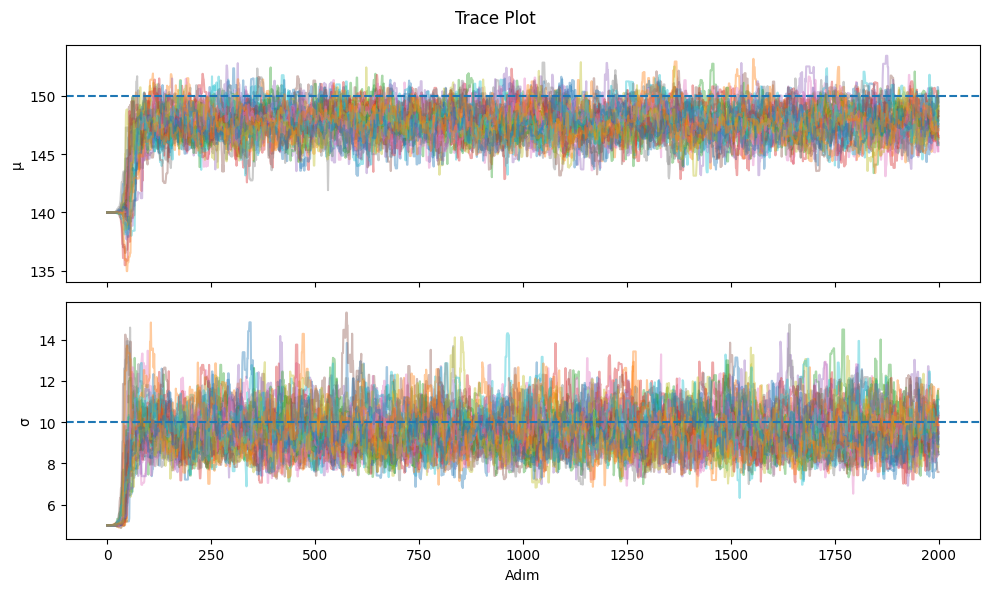

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(chain[:, :, 0], alpha=0.4)
axes[0].axhline(true_mu, linestyle="--")
axes[0].set_ylabel("μ")

axes[1].plot(chain[:, :, 1], alpha=0.4)
axes[1].axhline(true_sigma, linestyle="--")
axes[1].set_ylabel("σ")
axes[1].set_xlabel("Adım")

fig.suptitle("Trace Plot")
plt.tight_layout()
plt.savefig("outputs/trace_plot.png", dpi=300)
plt.show()

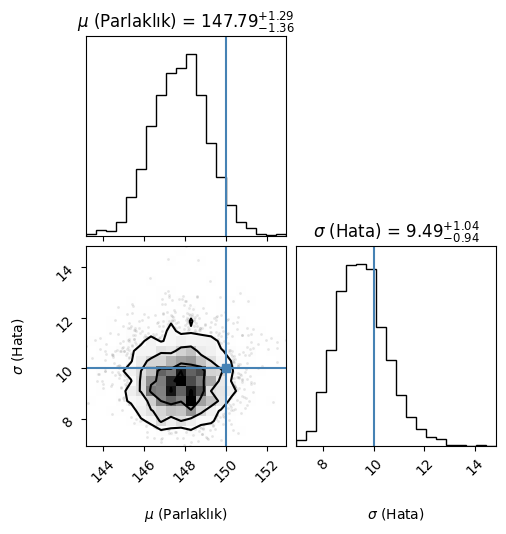

In [9]:
fig = corner.corner(
    flat_samples,
    labels=[r"$\mu$ (Parlaklık)", r"$\sigma$ (Hata)"],
    truths=[true_mu, true_sigma],
    show_titles=True
)
fig.savefig("outputs/corner_plot.png", dpi=300)
plt.show()

## 4. Sonuçların Hesaplanması
Bu bölümde posterior median, %16, %84 ve mutlak hata değerleri hesaplanmıştır.

In [10]:
mu_samples = flat_samples[:, 0]
sigma_samples = flat_samples[:, 1]

mu_p16, mu_p50, mu_p84 = np.percentile(mu_samples, [16, 50, 84])
sigma_p16, sigma_p50, sigma_p84 = np.percentile(sigma_samples, [16, 50, 84])

mu_abs_error = abs(mu_p50 - true_mu)
sigma_abs_error = abs(sigma_p50 - true_sigma)

print("μ sonuçları")
print("Median:", mu_p50)
print("%16:", mu_p16)
print("%84:", mu_p84)
print("Mutlak hata:", mu_abs_error)

print("\nσ sonuçları")
print("Median:", sigma_p50)
print("%16:", sigma_p16)
print("%84:", sigma_p84)
print("Mutlak hata:", sigma_abs_error)

μ sonuçları
Median: 147.7862533013905
%16: 146.42607424611114
%84: 149.07203239392416
Mutlak hata: 2.213746698609498

σ sonuçları
Median: 9.492117308421232
%16: 8.554305529485836
%84: 10.531275879457391
Mutlak hata: 0.507882691578768


In [11]:
print("Parametre Karşılaştırma Tablosu")
print("-" * 70)
print(f"μ (Parlaklık) | Gerçek: {true_mu:.1f} | Median: {mu_p50:.4f} | Alt %16: {mu_p16:.4f} | Üst %84: {mu_p84:.4f} | Mutlak Hata: {mu_abs_error:.4f}")
print(f"σ (Hata Payı) | Gerçek: {true_sigma:.1f} | Median: {sigma_p50:.4f} | Alt %16: {sigma_p16:.4f} | Üst %84: {sigma_p84:.4f} | Mutlak Hata: {sigma_abs_error:.4f}")

Parametre Karşılaştırma Tablosu
----------------------------------------------------------------------
μ (Parlaklık) | Gerçek: 150.0 | Median: 147.7863 | Alt %16: 146.4261 | Üst %84: 149.0720 | Mutlak Hata: 2.2137
σ (Hata Payı) | Gerçek: 10.0 | Median: 9.4921 | Alt %16: 8.5543 | Üst %84: 10.5313 | Mutlak Hata: 0.5079


## 5.1 Parametre Karşılaştırma Tablosu

| Değişken | Gerçek Değer (Girdi) | Tahmin Edilen (Median) | Alt Sınır (%16) | Üst Sınır (%84) | Mutlak Hata |
|---|---:|---:|---:|---:|---:|
| μ (Parlaklık) | 150.0 | 147.7863 | 146.4261 | 149.0720 | 2.2137 |
| σ (Hata Payı) | 10.0 | 9.4921 | 8.5543 | 10.5313 | 0.5079 |

## 6.1 Merkezi Eğilim ve Doğruluk (Accuracy) Analizi

Bayesyen çıkarım sonucu parlaklık parametresi için elde edilen tahmin değeri μ = 147.7863 olmuştur. Gerçek değer 150.0 olduğundan mutlak hata 2.2137’dir. Veri setinde gürültü bulunmasına rağmen tahminin gerçek değere oldukça yakın olduğu görülmektedir. Bu sonuç, yöntemin gözlem gürültüsü altında bile makul derecede doğru bir tahmin üretebildiğini göstermektedir. Hata sıfır değildir, ancak 150.0 gibi bir değer için yaklaşık 2.21 birimlik sapma kabul edilebilir düzeydedir. Ölçüm hassasiyeti parametresi için ise σ = 9.4921 tahmin edilmiştir ve gerçek değer olan 10.0’a oldukça yakındır. Bu parametredeki mutlak hata 0.5079 olup modelin belirsizliği de iyi yakaladığını göstermektedir.

## 6.2 Tahmin Hassasiyeti (Precision) Karşılaştırması

İstatistiksel olarak ortalama μ tahmini genellikle standart sapma σ tahminine göre daha kesindir. Bunun temel nedeni, ortalamanın çoklu gözlemler üzerinden daha kararlı biçimde hesaplanması ve belirsizliğinin yaklaşık olarak σ / √n ile azalmasıdır. Buna karşılık σ tahmini, verinin saçılmasına bağlı olduğu için ikinci dereceden moment içerir ve genellikle daha oynaktır. Bu nedenle veri sayısı arttıkça ortalama tahmini daha hızlı kararlı hale gelir. Bu ödevde n=50 olması, parametre tahminlerinin genel olarak dar bir aralıkta toplanmasına yardımcı olmuştur. Her ne kadar bu çalıştırmada güven aralığı genişlikleri birbirine yakın görünse de, teorik olarak daha fazla veri ortalama tahminini daha güvenilir hale getirir.

## 6.3 Olasılıksal Korelasyon Analizi

Corner Plot’ta μ ve σ parametrelerinin ortak dağılımı incelendiğinde, elips yapısının belirgin biçimde güçlü bir eğime sahip olmadığı görülmektedir. Bu durum, parlaklık tahmini ile gözlem hatası tahmini arasında güçlü bir doğrusal bağımlılık olmadığını gösterir. Yani iki parametre tamamen bağımsız olmasa da aralarında yüksek düzeyli bir korelasyon bulunduğu söylenemez. Posterior dağılım daha çok gerçekçi parametre bölgesinde yoğunlaşmıştır.

## 7. Prior Etkisi
Bu bölümde çok dar bir prior seçildiğinde sonucun nasıl değiştiği incelenmiştir.

In [12]:
def log_prior_narrow(theta):
    mu, sigma = theta
    if 100 < mu < 110 and 0 < sigma < 50:
        return 0.0
    return -np.inf

def log_probability_narrow(theta, data):
    lp = log_prior_narrow(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

initial_narrow = [105, 5]
pos_narrow = initial_narrow + 1e-4 * np.random.randn(n_walkers, n_dim)

sampler_narrow = emcee.EnsembleSampler(
    n_walkers, n_dim, log_probability_narrow, args=(data,)
)

sampler_narrow.run_mcmc(pos_narrow, 2000, progress=True)

flat_samples_narrow = sampler_narrow.get_chain(discard=500, thin=15, flat=True)
mu_narrow = flat_samples_narrow[:, 0]
sigma_narrow = flat_samples_narrow[:, 1]

mu_n_p16, mu_n_p50, mu_n_p84 = np.percentile(mu_narrow, [16, 50, 84])

print("Dar prior altında μ:")
print("Median:", mu_n_p50)
print("%16:", mu_n_p16)
print("%84:", mu_n_p84)

You must install the tqdm library to use progress indicators with emcee


Dar prior altında μ:
Median: 109.41651407888497
%16: 108.47089339817491
%84: 109.85271822291458


### Prior Etkisi Yorumu

Parlaklık için çok dar bir prior seçildiğinde (100 < μ < 110), posterior dağılım veri yerine prior sınırları tarafından baskılanmıştır. Bu deneyde μ için median değer 109.4165 bulunmuştur. Gerçek değer 150.0 olmasına rağmen sonucun 109 civarında kalması, çok kısıtlayıcı ve yanlış bir prior’un Bayesyen tahmini ciddi biçimde saptırabileceğini göstermektedir. Dolayısıyla prior seçimi dikkatli yapılmalıdır; aksi halde model veriden gelen bilgiyi tam olarak yansıtamaz.

## 8. Veri Miktarı Etkisi
Bu bölümde gözlem sayısı 50’den 5’e düşürüldüğünde posterior dağılımın nasıl değiştiği incelenmiştir.

In [13]:
n_obs_small = 5
np.random.seed(42)
data_small = true_mu + true_sigma * np.random.randn(n_obs_small)

initial_small = [140, 5]
pos_small = initial_small + 1e-4 * np.random.randn(n_walkers, n_dim)

sampler_small = emcee.EnsembleSampler(
    n_walkers, n_dim, log_probability, args=(data_small,)
)

sampler_small.run_mcmc(pos_small, 2000, progress=True)

flat_samples_small = sampler_small.get_chain(discard=500, thin=15, flat=True)

mu_small = flat_samples_small[:, 0]
sigma_small = flat_samples_small[:, 1]

mu_s_p16, mu_s_p50, mu_s_p84 = np.percentile(mu_small, [16, 50, 84])
sigma_s_p16, sigma_s_p50, sigma_s_p84 = np.percentile(sigma_small, [16, 50, 84])

print("n=5 için μ")
print("Median:", mu_s_p50)
print("%16:", mu_s_p16)
print("%84:", mu_s_p84)

print("\nn=5 için σ")
print("Median:", sigma_s_p50)
print("%16:", sigma_s_p16)
print("%84:", sigma_s_p84)

You must install the tqdm library to use progress indicators with emcee


n=5 için μ
Median: 155.0044294207881
%16: 150.65709796357245
%84: 159.31710788070941

n=5 için σ
Median: 8.908581096224932
%16: 6.056977996474343
%84: 14.545789260944654


### Veri Miktarı Etkisi Yorumu

Gözlem sayısı 50’den 5’e düşürüldüğünde posterior dağılım belirgin biçimde genişlemiştir. Ana deneyde μ için %16-%84 aralığı [146.4261, 149.0720] iken, n=5 durumunda bu aralık [150.6571, 159.3171] olmuştur. Bu durum, az veri ile yapılan tahminlerde belirsizliğin arttığını göstermektedir. Veri sayısı azaldıkça model parametreleri hakkında daha az bilgi elde edilir ve posterior dağılım daha geniş hale gelir. Bu nedenle daha fazla gözlem, daha güvenilir ve daha hassas tahminler sağlar.

## 9. Sonuç

Bu çalışmada Bayesyen çıkarım ve MCMC kullanılarak sentetik astronomik gözlem verilerinden parlaklık ve hata payı parametreleri tahmin edilmiştir. Elde edilen sonuçlar gerçek değerlere yakın çıkmış, özellikle μ ve σ için makul doğruluk sağlanmıştır. Ayrıca dar prior kullanımının tahmini ciddi biçimde etkileyebildiği ve veri sayısının azalmasının posterior belirsizliği artırdığı gösterilmiştir.